In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss
from math import factorial

# Part 1

In [2]:
# Parameters
rng = np.random.default_rng(30)
m = 10
A = 8
g = lambda i: A**i/factorial(i)


# Simulate
N = 10_000
X = np.empty(N, dtype=np.int64)
Y = np.empty_like(X)
X[0] = 0
for i in range(N-1):
    Y[i] = rng.integers(0,m+1)
    gY = g(Y[i])
    gX = g(X[i])

    if gY >= gX:
        X[i+1] = Y[i]
    else:
        accept = rng.choice([0,1], p=[1-gY/gX, gY/gX])
        if accept:
            X[i+1] = Y[i]
        else:
            X[i+1] = X[i]

$\chi^2$-test

In [3]:
burn_in = 1_000

# Expected 
p = np.array([g(i) for i in range(m+1)])
exp = (p / np.sum(p))

# Observed
obs = np.bincount(X[burn_in:], minlength=m+1)
obs = obs/np.sum(obs)

# Chisq-test
chi2_stat, p_value = ss.chisquare(obs, exp, ddof=0)
print(chi2_stat, p_value)

0.002591768717320412 1.0


<BarContainer object of 11 artists>

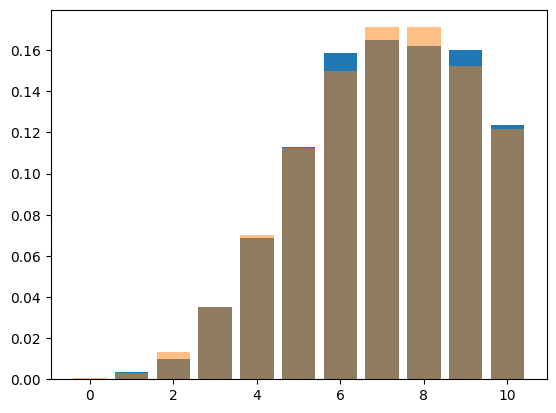

In [4]:
plt.bar(np.linspace(0,10,11),obs)
plt.bar(np.linspace(0,10,11),exp,alpha=0.5)

# Part 2

Use the Metropolis-Hastings algorithm directly to generate samples from the
distribution

In [5]:
rng = np.random.default_rng(30)

A1 = 4
A2 = 4
m = 10

def g(i, j):
    return (A1**i / factorial(i)) * (A2**j / factorial(j))

N = 10_000

IJ = np.zeros((N, 2), dtype=int)

# initial valid state
IJ[0] = (0, 0)

for t in range(N - 1):

    i, j = IJ[t]

    # propose new state
    while True:
        i_new = rng.integers(0, m + 1)
        j_new = rng.integers(0, m + 1)
        if i_new + j_new <= m:
            break

    # MH acceptance ratio
    g_new = g(i_new, j_new)
    g_old = g(i, j)

    alpha = min(1.0, g_new / g_old)

    if rng.random() < alpha:
        IJ[t + 1] = (i_new, j_new)
    else:
        IJ[t + 1] = (i, j)

0.017267488096493096 1.0


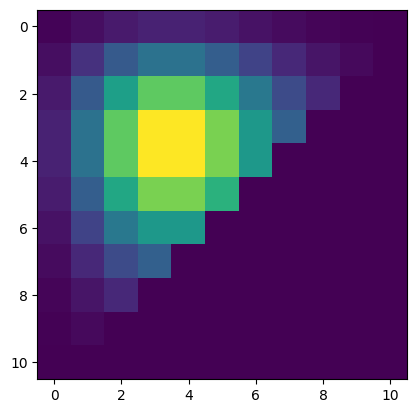

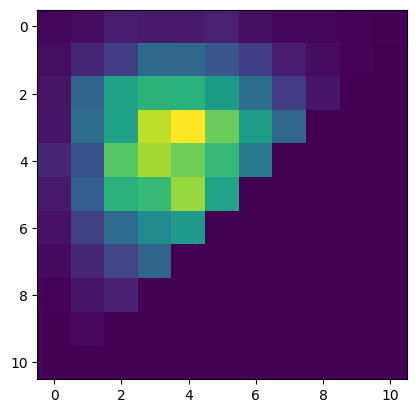

In [6]:
burn_in = 1_000

# Expected 
p = np.empty((m+1,m+1))
for ii in range(m+1):
    for jj in range(m+1):
        if ii+jj > m:
            p[ii,jj] = 0
        else:
            p[ii,jj] = g(ii,jj)

exp = p / np.sum(p)

# Observed
obs = np.zeros((m+1,m+1))
for (i,j) in IJ:
    obs[i,j] += 1
obs = obs / np.sum(obs)

# Chisq-test
chi2_stat, p_value = ss.chisquare(obs[np.nonzero(obs)], exp[np.nonzero(exp)], ddof=0)
print(chi2_stat, p_value)

plt.imshow(p)
plt.show()
plt.imshow(obs)
plt.show()

### Use coordinatewise Metropolis-Hastings to generate samples from the distribution.

In [7]:
rng = np.random.default_rng(30)

A1 = 4
A2 = 4
m = 10

def g(i, j):
    return (A1**i / factorial(i)) * (A2**j / factorial(j))

N = 10_000

IJ = np.zeros((N, 2), dtype=int)

# init
IJ[0] = (0, 0)

for t in range(N - 1):

    i, j = IJ[t]

    # Step 1: update i | j
    i_new = rng.integers(0, m - j + 1)

    g_new = g(i_new, j)
    g_old = g(i, j)

    alpha = min(1.0, g_new / g_old)

    if rng.random() < alpha:
        i = i_new

    # Step 2: update j | i
    j_new = rng.integers(0, m - i + 1)

    g_new = g(i, j_new)
    g_old = g(i, j)

    alpha = min(1.0, g_new / g_old)

    if rng.random() < alpha:
        j = j_new

    IJ[t + 1] = (i, j)

0.003438011895978261 1.0


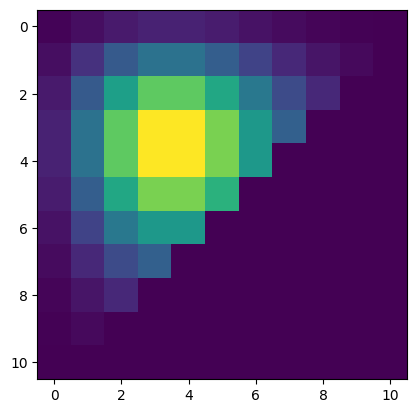

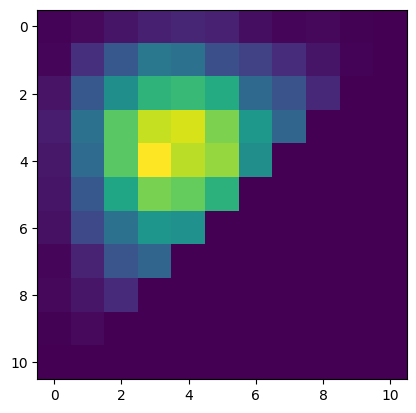

In [8]:
burn_in = 1_000

# Expected 
p = np.empty((m+1,m+1))
for ii in range(m+1):
    for jj in range(m+1):
        if ii+jj > m:
            p[ii,jj] = 0
        else:
            p[ii,jj] = g(ii,jj)

exp = p / np.sum(p)

# Observed
obs = np.zeros((m+1,m+1))
for (i,j) in IJ:
    obs[i,j] += 1
obs = obs / np.sum(obs)

# Chisq-test
chi2_stat, p_value = ss.chisquare((obs+0.01).flatten(), (exp+0.01).flatten(), ddof=0)
print(chi2_stat, p_value)

plt.imshow(p)
plt.show()
plt.imshow(obs)
plt.show()

### Use Gibbs sampling to generate samples from the distribution

In [52]:
rng = np.random.default_rng(30)

A1 = 4
A2 = 4
m = 10

def g(i, j):
    return (A1**i / factorial(i)) * (A2**j / factorial(j))

N = 10_000

IJ = np.zeros((N, 2), dtype=int)

# init
IJ[0] = (0, 0)

# Calculate conditional propabilities
cond_prop_j = np.zeros((m+1,m+1))
for j in range(m+1):
    props = np.array([(A1**i / factorial(i)) for i in range(m-j+1)])
    cond_prop_j[j,:m-j+1] = props / props.sum()

cond_prop_i = np.zeros((m+1,m+1))
for i in range(m+1):
    props = np.array([(A2**j / factorial(j)) for j in range(m-i+1)])
    cn = 1/np.sum(props)
    cond_prop_i[i,:m-i+1] = props / props.sum()

## these are the same because A1=A2

for t in range(N - 1):

    i, j = IJ[t]

    # sample
    i_new = rng.choice(m+1, p=cond_prop_i[j])
    j_new = rng.choice(m+1, p=cond_prop_j[i_new])

    # update
    IJ[t + 1] = (i_new, j_new)

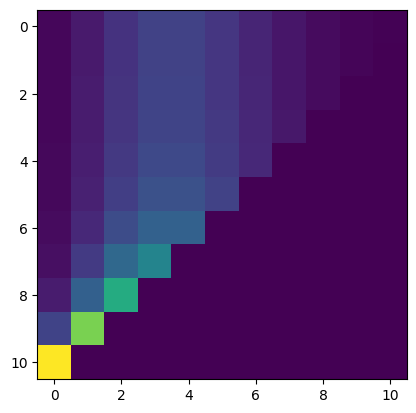

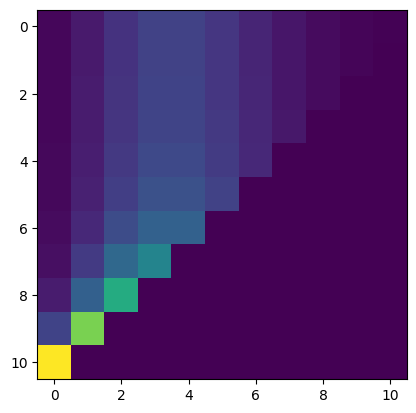

In [53]:
plt.imshow(cond_prop_j)
plt.show()
plt.imshow(cond_prop_i)

0.002468765158553726 1.0


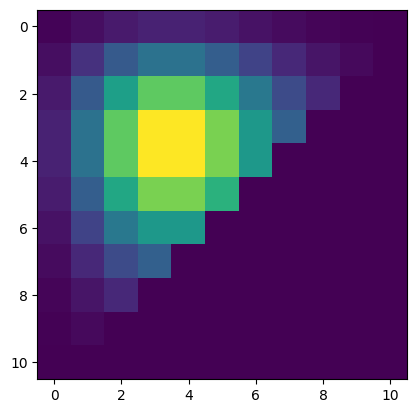

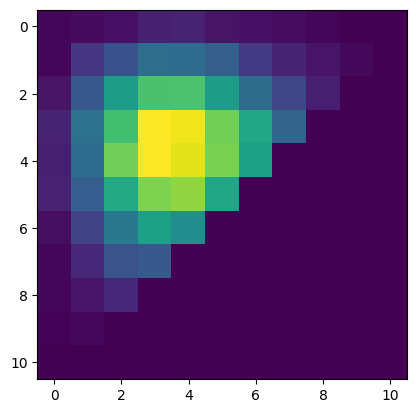

In [54]:
burn_in = 1_000

# Expected 
p = np.empty((m+1,m+1))
for ii in range(m+1):
    for jj in range(m+1):
        if ii+jj > m:
            p[ii,jj] = 0
        else:
            p[ii,jj] = g(ii,jj)

exp = p / np.sum(p)

# Observed
obs = np.zeros((m+1,m+1))
for (i,j) in IJ:
    obs[i,j] += 1
obs = obs / np.sum(obs)

# Chisq-test
chi2_stat, p_value = ss.chisquare((obs+0.01).flatten(), (exp+0.01).flatten(), ddof=0)
print(chi2_stat, p_value)

plt.imshow(p)
plt.show()
plt.imshow(obs)
plt.show()